# 핸즈온 머신러닝 2장 실습 — House Prices (Kaggle)

> **이전 글**: [핸즈온머신러닝 2장 - End to End ML Project](https://velog.io/@justnormguy/핸즈온머신러닝-2.end-to-end-ML-Project)  
> California Housing 이후, 더 복잡한 데이터(79개 특성, 결측치 다수)로 동일한 End-to-End 플로우를 적용한 실습 기록.

**이번 실습의 핵심:**
- 결측치 처리 전략 (결측의 의미를 파악하고 처리)
- Data Leakage 개념 이해 및 Pipeline으로 방지
- 계층적 샘플링 vs 랜덤 샘플링 비교

**사용 데이터:** [House Prices: Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)  
**최종 점수:** RMSLE 0.15074 (RandomForest baseline)

---

## 0. 환경 설정 및 데이터 로드

Kaggle API로 House Prices 데이터셋을 다운로드하고 압축을 해제함.

> `kaggle.json`은 Kaggle → Settings → API에서 발급 후, 프로젝트 루트에 위치시켜야 함.

```
kaggle.json 위치: ~/.kaggle/kaggle.json (Linux/Mac) 또는 %USERPROFILE%\.kaggle\kaggle.json (Windows)
```

In [ ]:
import os
import zipfile

import kaggle

# 다운로드
kaggle.api.competition_download_files(
    "house-prices-advanced-regression-techniques", path="./data"
)

# 압축 해제
with zipfile.ZipFile(
    "./data/house-prices-advanced-regression-techniques.zip", "r"
) as z:
    z.extractall("./data")

print(os.listdir("./data"))

['data_description.txt', 'house-prices-advanced-regression-techniques.zip', 'sample_submission.csv', 'test.csv', 'train.csv']


---

### 한국어 폰트 설정 (Colab 전용)

Colab에서 matplotlib 한국어가 깨지는 경우 나눔고딕 폰트를 설치해야 함.  
로컬 환경(VSCode, Jupyter)에서는 이 셀 불필요.

> Windows 환경에서는 아래 폰트 설정 셀에서 `Malgun Gothic` 사용.

In [2]:
### 글자 깨짐 방지 위해 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

'apt-get'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'fc-cache'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


---

## 1. 데이터 파악

`train.csv`를 로드하고 기본 형태를 확인함.

In [5]:
import pandas as pd

data = pd.read_csv("data/train.csv")

# 데이터 모양  확인
print("shape : ", data.shape)

shape :  (1460, 81)


---

### 전체 컬럼 구조 확인

- 총 81개 컬럼 (수치형 38개, 범주형 43개, 타겟 SalePrice 1개)
- `info()`로 각 컬럼의 dtype과 결측치 여부를 한눈에 확인할 수 있음.
- **주의**: `MSSubClass`처럼 숫자로 되어 있지만 실제로는 건물 유형 코드인 컬럼 존재 → 수치형으로 취급하면 안 됨.

In [6]:
# 전체적인 데이터 확인
# 결측치있는 데이터 존재
# 수치형 / 범주형 혼재

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

---

### 수치형 / 범주형 컬럼 분리

- 전체 컬럼 목록에서 수치형을 제외한 나머지를 범주형으로 분류함.
- `select_dtypes` 대신 집합 연산(set difference)을 사용한 방식.

In [7]:
### 모든 컬럼 불러오기
a_col = data.columns.tolist()
print("모든 컬럼 : ", a_col)

### 수치형 데이터 리스트
n_col = data._get_numeric_data().columns.tolist()
print("수치형 컬럼 : ", n_col)

### 범주형 데이터 리스트
c_col = list(set(a_col) - set(n_col))
print("범주형 데이터 : ", c_col)

모든 컬럼 :  ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',

---

## 2. 결측치 파악

결측치가 있는 컬럼을 내림차순으로 출력함.

California Housing은 결측치가 `total_bedrooms` 하나뿐이었지만,  
House Prices는 **19개 컬럼**에 결측치가 존재함.

### 결측치 처리 전략

결측치를 무조건 중간값으로 채우면 안 됨. **결측의 의미**를 먼저 파악해야 함.

| 유형 | 해당 컬럼 예시 | 처리 방법 |
|------|-----------|-----------|
| 결측 = 해당 시설 없음 (범주형) | PoolQC, Alley, Fence, FireplaceQu, GarageType 등 | `"None"` 채우기 |
| 결측 = 해당 시설 없음 (수치형) | MasVnrArea | `0` 채우기 |
| 진짜 누락된 값 | LotFrontage, Electrical, GarageYrBlt | `SimpleImputer`로 처리 |

> `PoolQC`가 비어있다 = 수영장이 없다는 뜻. 중간값보다 `"None"`이 의미상 맞음.

In [8]:
# 결측치 찾기
missing_col = data.isnull().sum()
print(missing_col[missing_col > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


---

## 3. EDA — 타겟(SalePrice) 분포 확인

시각화 전 폰트 설정. Windows 환경에서는 `Malgun Gothic` 사용.

In [ ]:
import matplotlib.pyplot as plt

# 맑은 고딕 사용 (Windows 기본 내장)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

---

### SalePrice 원본 분포

오른쪽으로 꼬리가 긴 **right-skewed (양의 왜도)** 분포.  
극단적으로 비싼 집 일부가 분포를 오른쪽으로 끌어당기는 것.

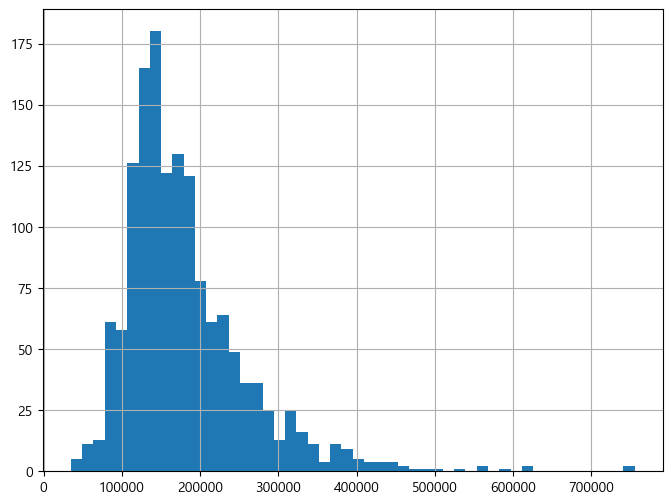

In [11]:
data["SalePrice"].hist(bins=50, figsize=(8, 6))
plt.show()

---

### 로그 변환 후 분포

- `FunctionTransformer`를 사용해 `np.log` 변환 적용 (역변환 함수: `np.exp`)
- 선형 회귀 계열 모델은 타겟이 정규분포에 가까울 때 더 잘 작동함 → 로그 변환이 필요한 이유

> 예측 후 원래 스케일로 돌릴 때는 `np.expm1()` 또는 `np.exp()` 역변환 사용.

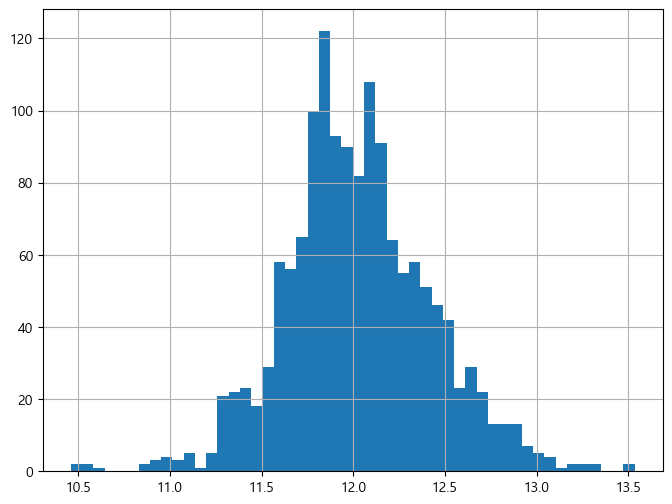

In [ ]:
### 로그로 치환
import numpy as np
from sklearn.preprocessing import FunctionTransformer

### 역변환 함수 = 지수 / 변환함수 = 로그함수
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_sales = log_transformer.transform(data["SalePrice"])
log_sales.hist(bins=50, figsize=(8, 6))
plt.show()

---

### 원본 vs 로그 변환 비교 (subplot)

- 왼쪽: 원본 분포 (right-skewed)
- 오른쪽: 로그 변환 후 분포 (정규분포에 근접)

두 그래프를 나란히 놓으면 차이가 명확하게 보임.

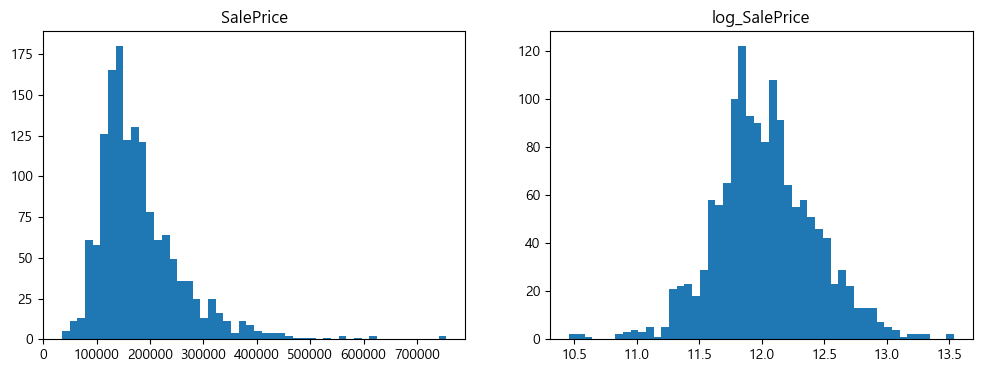

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 첫 번째 그래프
axes[0].hist(data["SalePrice"], bins=50)
axes[0].set_title("SalePrice")

# 두 번째 그래프
axes[1].hist(log_sales, bins=50)
axes[1].set_title("log_SalePrice")

plt.show()

---

## 4. 상관관계 분석

수치형 컬럼들과 `SalePrice` 간의 상관계수를 계산하고 상위 10개를 출력함.

**상위 결과 해석:**
- `OverallQual`(0.79): 전반적인 품질 — 압도적 1위
- `GrLivArea`(0.71): 지상 거주 면적
- `GarageCars`(0.64) & `GarageArea`(0.62): 사실상 같은 정보 → **다중공선성** 주의

대각선이 모두 1.0인 이유: 자기 자신과의 상관계수이기 때문.

In [14]:
### 상관계수 계산
corr_matrix = data.corr(numeric_only=True)

### 상관계수 행렬 출력
print("상관 계수 - SalePrice 상관계수 출력 ")

corr_matrix["SalePrice"].sort_values(ascending=False).head(10)

상관 계수 - SalePrice 상관계수 출력 


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

---

### 상관관계 Heatmap

- SalePrice와 상관계수 상위 10개 컬럼만 추출해서 시각화
- `cmap="coolwarm"`: 높은 상관관계(빨강) ~ 낮은 상관관계(파랑)으로 직관적으로 파악 가능

전체 38x38 행렬을 그리면 복잡해서 읽기 어려움 → 상위 특성만 추려서 그리는 것이 효과적.

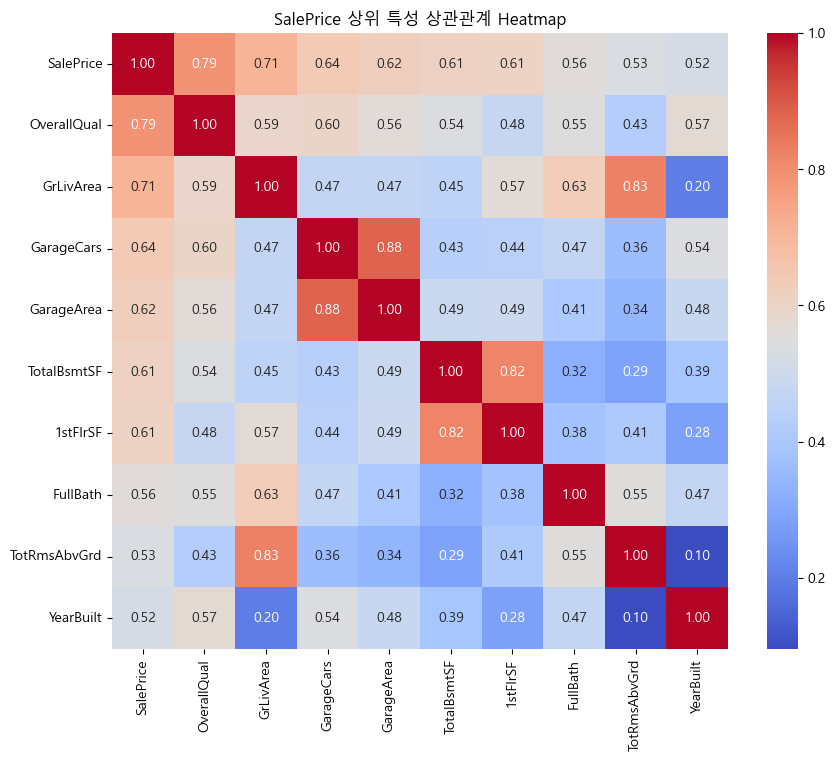

In [ ]:
import seaborn as sns

# 1단계 — SalePrice 상관계수 상위 10개 컬럼만 추출
top_features = corr_matrix["SalePrice"].sort_values(ascending=False).head(10).index

# 2단계 — 그 컬럼들만의 상관행렬로 heatmap
plt.figure(figsize=(10, 8))  # 크기 지정
sns.heatmap(
    corr_matrix[top_features].loc[top_features],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  # 색상 — 파랑(음수) ~ 빨강(양수)
    square=True,  # 정사각형으로
)
plt.title("SalePrice 상위 특성 상관관계 Heatmap")
plt.show()

---

### 기본 통계량 확인

`describe()`로 각 수치형 컬럼의 min, max, 분위수 등을 확인함.

> **SalePrice 분위수 확인:**
> - 25%: 129,975
> - 50%: 163,000  
> - 75%: 214,000
>
> → 계층적 샘플링을 위한 bins 구간 설정에 활용.

In [17]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


---

## 5. 계층적 샘플링

California Housing에서는 `median_income`을 기준으로 계층적 샘플링을 했음.  
이번엔 타겟인 `SalePrice`를 직접 기준으로 삼음.

`describe()`의 25%/50%/75% 값을 bins 경계로 사용 → 각 구간에 균등하게 데이터 분포.

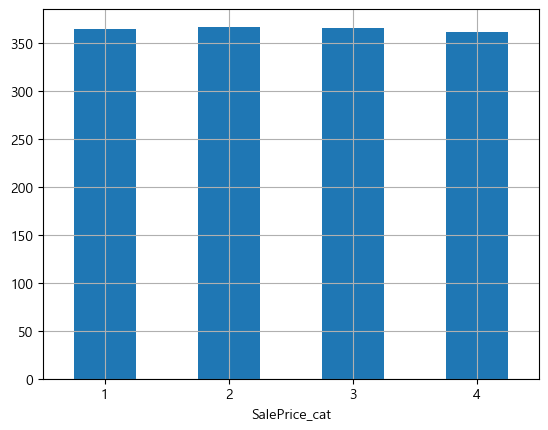

In [18]:
data["SalePrice_cat"] = pd.cut(
    data["SalePrice"], bins=[0, 129975, 163000, 214000, np.inf], labels=[1, 2, 3, 4]
)

### 시각화 진행
data["SalePrice_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.show()

In [19]:
data["SalePrice_cat"].value_counts().sort_index()

SalePrice_cat
1    365
2    367
3    366
4    362
Name: count, dtype: int64

---

### 계층적 샘플링 적용

`stratify=data["SalePrice_cat"]`를 지정하면 훈련/테스트 세트 모두 각 가격 구간 비율이 유지됨.

In [ ]:
from sklearn.model_selection import train_test_split

strat_train, strat_test = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data["SalePrice_cat"]
)

---

### 랜덤 샘플링 (비교용)

계층적 샘플링과 단순 랜덤 샘플링의 결과를 비교하기 위해 랜덤 분할도 수행.

In [22]:
### train_test_split으로 단순하게 나누기

# SalePrice_cat 추가 후 다시 랜덤 분할
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

---

### 두 방식의 비율 비교

계층적 샘플링이 전체 비율(0.25)에 더 가깝게 유지됨.  
랜덤 샘플링은 특정 구간에서 편차가 발생 → 모델이 그 가격대 데이터를 덜 학습하게 됨.

In [23]:
compare = pd.DataFrame(
    {
        "전체": data["SalePrice_cat"].value_counts(normalize=True).sort_index(),
        "계층적": strat_test["SalePrice_cat"].value_counts(normalize=True).sort_index(),
        "랜덤": test_set["SalePrice_cat"].value_counts(normalize=True).sort_index(),
    }
)
print(compare.round(4))

                   전체     계층적      랜덤
SalePrice_cat                        
1              0.2500  0.2500  0.2774
2              0.2514  0.2534  0.2740
3              0.2507  0.2500  0.2158
4              0.2479  0.2466  0.2329


---

### SalePrice_cat 컬럼 제거

**제거 이유:**
1. `SalePrice_cat`은 `SalePrice`를 기반으로 만든 컬럼
2. 모델에 넣으면 타겟 정보가 특성으로 유입되는 **Data Leakage** 발생
3. 불필요한 특성은 모델에 노이즈가 됨

In [24]:
# 사용 후 SalePrice_cat 컬럼 제거
for df in (strat_train, strat_test):
    df.drop("SalePrice_cat", axis=1, inplace=True)

---

## 6. 특성 / 타겟 분리

훈련 데이터에서 타겟(`SalePrice`)을 분리함.

In [25]:
# 훈련/테스트 특성과 타겟 분리
housing = strat_train.drop("SalePrice", axis=1)
housing_labels = strat_train["SalePrice"].copy()

In [26]:
print("housing.shape : ", housing.shape)
print("housing_labels.shape : ", housing_labels.shape)

housing.shape :  (1168, 80)
housing_labels.shape :  (1168,)


---

### 수치형 / 범주형 컬럼 수 확인

Pipeline 구성을 위해 수치형 컬럼과 범주형 컬럼의 개수를 확인함.

In [27]:
# 각각 몇 개인지 확인
print(housing.select_dtypes(include=["number"]).shape[1])
print(housing.select_dtypes(include=["object"]).shape[1])

37
43


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37316\301540868.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(housing.select_dtypes(include=['object']).shape[1])


---

## 7. Pipeline 구성 — 이번 실습의 핵심

### Data Leakage란?

모델 평가에 쓸 테스트 데이터의 정보가 훈련 과정에 미리 흘러들어가는 것.

**잘못된 방식 (Leakage 발생):**
```python
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)  # 테스트 데이터의 평균/표준편차가 반영됨
```

**올바른 방식:**
```python
scaler.fit_transform(X_train)  # 훈련 데이터로만 fit
scaler.transform(X_test)       # 테스트엔 transform만
```

**Pipeline이 이를 구조적으로 보장함:**
- `pipeline.fit(X_train)` → 내부 변환기들이 훈련 데이터로만 `fit`
- `pipeline.predict(X_test)` → `transform`만 적용
- 실수할 여지 자체를 없애주는 것

### 수치형 파이프라인
- `SimpleImputer(strategy="median")`: 결측치 → 중간값으로 대체
- `StandardScaler()`: 평균 0, 표준편차 1로 정규화

### 범주형 파이프라인
- `SimpleImputer(strategy="most_frequent")`: 결측치 → 최빈값으로 대체
- `OneHotEncoder(handle_unknown="ignore")`: 범주 → 이진 벡터 변환. `ignore`는 훈련에 없던 카테고리를 테스트에서 만나도 에러 없이 처리함.

In [ ]:
### 파이프라인 만들기
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 수치형 파이프라인
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

# 범주형 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")
)

---

### ColumnTransformer로 파이프라인 결합

수치형 컬럼과 범주형 컬럼에 각각 다른 파이프라인을 적용함.

`ColumnTransformer`는 `("이름", 파이프라인, 적용할_컬럼)` 튜플의 리스트를 받음.

In [29]:
from sklearn.compose import ColumnTransformer

# 수치형 / 범주형 컬럼 리스트
num_cols = housing.select_dtypes(include=["number"]).columns.tolist()
cat_cols = housing.select_dtypes(include=["object"]).columns.tolist()

preprocessing = ColumnTransformer(
    [
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37316\3792263424.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = housing.select_dtypes(include=['object']).columns.tolist()


---

### 전처리 결과 확인

원래 80개 컬럼이 `fit_transform` 후 284개로 늘어남.

**이유:**
- 수치형 37개 → 그대로 37개
- 범주형 43개 → OneHotEncoding 후 247개 (각 카테고리 수만큼 컬럼 생성)

> `Neighborhood` 하나만 해도 25개 지역 = 25개 컬럼이 됨.

In [31]:
housing_prepared = preprocessing.fit_transform(housing)
print("housing_prepared.shape : ", housing_prepared.shape)

housing_prepared.shape :  (1168, 284)


---

## 8. 전체 파이프라인 + 모델 훈련

전처리 파이프라인과 모델을 하나로 합침.

`random_state=42`를 설정하는 이유: 매번 같은 결과를 재현하기 위함.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("model", RandomForestRegressor(random_state=42)),
    ]
)

---

### 파이프라인 학습

`full_pipeline.fit(housing, housing_labels)` 한 번으로:
1. `preprocessing` 단계: 훈련 데이터로 `fit_transform`
2. `model` 단계: 변환된 데이터로 `fit`

이후 `predict()`할 때는 `transform`만 자동 적용됨.

In [33]:
full_pipeline.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

---

## 9. 모델 평가

### 훈련 세트 RMSE

훈련 데이터에 대한 예측 오차. 이 값만으로는 실제 성능을 판단하기 어려움.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

housing_predictions = full_pipeline.predict(housing)
rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
print(f"훈련 세트 RMSE: {rmse:,.0f}")

훈련 세트 RMSE: 10,432


---

### 오차율 해석

SalePrice 평균(179,491달러) 대비 훈련 RMSE의 비율.

In [35]:
print(f"SalePrice 평균: {housing_labels.mean():,.0f}")
print(f"오차율: {10432 / housing_labels.mean() * 100:.1f}%")

SalePrice 평균: 179,491
오차율: 5.8%


---

### 교차검증 RMSE

훈련 RMSE(10,432)와 교차검증 RMSE(27,735)의 차이가 **2.6배**.

→ 모델이 훈련 데이터를 거의 외우다시피 학습함 = **과대적합(Overfitting)**

RandomForest는 기본 설정으로 트리를 매우 깊게 키워 훈련 데이터를 과도하게 학습함.

In [36]:
from sklearn.model_selection import cross_val_score

rmses = -cross_val_score(
    full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=5
)
print(f"교차검증 RMSE 평균: {rmses.mean():,.0f}")
print(f"교차검증 RMSE 표준편차: {rmses.std():,.0f}")

교차검증 RMSE 평균: 27,735
교차검증 RMSE 표준편차: 4,484


---

### 파이프라인 학습

`full_pipeline.fit(housing, housing_labels)` 한 번으로:
1. `preprocessing` 단계: 훈련 데이터로 `fit_transform`
2. `model` 단계: 변환된 데이터로 `fit`

이후 `predict()`할 때는 `transform`만 자동 적용됨.

In [ ]:
### LinearRegression 로 모델 변경
from sklearn.linear_model import LinearRegression

full_pipeline.set_params(model=LinearRegression())
full_pipeline.fit(housing, housing_labels)

housing_predictions_ln = full_pipeline.predict(housing)
rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions_ln))
print(f"훈련 세트 RMSE: {rmse:,.0f}")

print(f"SalePrice 평균: {housing_labels.mean():,.0f}")
print(f"오차율: {10432 / housing_labels.mean() * 100:.1f}%")

rmses = -cross_val_score(
    full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=5
)
print(f"교차검증 RMSE 평균: {rmses.mean():,.0f}")
print(f"교차검증 RMSE 표준편차: {rmses.std():,.0f}")

훈련 세트 RMSE: 17,917
SalePrice 평균: 179,491
오차율: 5.8%
교차검증 RMSE 평균: 32,323
교차검증 RMSE 표준편차: 9,744


- RandomForest가 교차검증 RMSE(27,735)는 더 낮음 → 예측 성능은 RandomForest가 더 좋음
- LinearRegression은 훈련/교차검증 차이가 조금 더 작음 → 과대적합이 적음
- RandomForest가 과대적합이 있긴 하지만 그럼에도 불구하고 성능 자체는 더 좋음

---

### 파이프라인 학습

`full_pipeline.fit(housing, housing_labels)` 한 번으로:
1. `preprocessing` 단계: 훈련 데이터로 `fit_transform`
2. `model` 단계: 변환된 데이터로 `fit`

이후 `predict()`할 때는 `transform`만 자동 적용됨.

In [40]:
### 튜닝하기 max_depth=10 / max_depth=20
full_pipeline.set_params(model=RandomForestRegressor(random_state=42, max_depth=10))
full_pipeline.fit(housing, housing_labels)
housing_predictions_10 = full_pipeline.predict(housing)
rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions_10))
print(f"훈련 세트 RMSE: {rmse:,.0f}")

print(f"SalePrice 평균: {housing_labels.mean():,.0f}")
print(f"오차율: {10432 / housing_labels.mean() * 100:.1f}%")

rmses = -cross_val_score(
    full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=5
)
print(f"교차검증 RMSE 평균: {rmses.mean():,.0f}")
print(f"교차검증 RMSE 표준편차: {rmses.std():,.0f}")

훈련 세트 RMSE: 11,525
SalePrice 평균: 179,491
오차율: 5.8%
교차검증 RMSE 평균: 27,946
교차검증 RMSE 표준편차: 4,586


---

### 파이프라인 학습

`full_pipeline.fit(housing, housing_labels)` 한 번으로:
1. `preprocessing` 단계: 훈련 데이터로 `fit_transform`
2. `model` 단계: 변환된 데이터로 `fit`

이후 `predict()`할 때는 `transform`만 자동 적용됨.

In [41]:
### 튜닝하기 max_depth=10 / max_depth=20
full_pipeline.set_params(model=RandomForestRegressor(random_state=42, max_depth=20))
full_pipeline.fit(housing, housing_labels)
housing_predictions_20 = full_pipeline.predict(housing)
rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions_20))
print(f"훈련 세트 RMSE: {rmse:,.0f}")

print(f"SalePrice 평균: {housing_labels.mean():,.0f}")
print(f"오차율: {10432 / housing_labels.mean() * 100:.1f}%")

rmses = -cross_val_score(
    full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=5
)
print(f"교차검증 RMSE 평균: {rmses.mean():,.0f}")
print(f"교차검증 RMSE 표준편차: {rmses.std():,.0f}")

훈련 세트 RMSE: 10,459
SalePrice 평균: 179,491
오차율: 5.8%
교차검증 RMSE 평균: 27,777
교차검증 RMSE 표준편차: 4,533


---

## 10. Kaggle 제출

`test.csv`는 `SalePrice` 컬럼이 없음 (80개 컬럼).  
훈련된 파이프라인으로 예측 후 제출 파일 생성.

**제출 방법:**
```bash
kaggle competitions submit \
  -c house-prices-advanced-regression-techniques \
  -f submissions/house_submission.csv \
  -m "RandomForest baseline"
```

**최종 결과: RMSLE 0.15074** (상위 40~50% 수준)

In [42]:
### 캐글 제출용
test_df = pd.read_csv("data/test.csv")
print(test_df.shape)

(1459, 80)


---

### 제출 파일 생성 및 확인

In [45]:
# 예측
test_predictions = full_pipeline.predict(test_df)

# 제출 파일 생성
submission = pd.DataFrame({"Id": test_df["Id"], "SalePrice": test_predictions})

submission.to_csv("submissions/house_submission.csv", index=False)
print(submission.head())

     Id      SalePrice
0  1461  130787.871041
1  1462  154882.750000
2  1463  176576.170000
3  1464  184072.148571
4  1465  205373.250000
